# Week 3 Report

**Date:** 06-08-2026 - 06-12-2026

## Goals for this week

- [ ] Begin refining scientific question
- [ ] Interpret Results of PCA
- [ ] Refine Linear Regression model
- [ ] Perform Linear Regression on PCA components

## What I did

*(Describe what you worked on. Include code cells below to show your analysis.)*

In [34]:
#not everything done this week is in a form that is easily transferrable to this report, so for remainder of work
# please refer to LassoRegression.ipynb and RidgeRegression.ipynb in the 6/12 git commit

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import scale
from sklearn import model_selection
from sklearn.preprocessing import scale
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold

pa_gs = pd.read_csv('/home/reu/project/data/pa_data.csv').dropna()
coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]

X = ['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico', 'sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']
y = ['growing_season_length']

#UPDATED PCA FUNCTION
def principal_component_analysis(X, y):
    #creates and graphs principal component analysis for inputted X and y
    #required libraries: from sklearn.preprocessing import StandardScalar, from sklearn.decomposition import PCA,
    #from sklearn.linear_model import LinearRegression, matplotlib.pyplot as plt, numpy as np, seaborn as sns

    #gets list of columns in input X for future conversion of X_train back into dataframe
    columns_X = list(X.columns)

    # splits data into X_train, X_test, y_train, and y_test and makes X_train a dataframe
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_train = pd.DataFrame(X_train, columns = columns_X)

    # First PCA
    pca1 = PCA()
    X_pca1 = pca1.fit_transform(X_train)
    plt.bar(range(1,len(pca1.explained_variance_)+1),pca1.explained_variance_)
    plt.ylabel('Explained Variance')
    plt.xlabel('Components')
    plt.plot(range(1,len(pca1.explained_variance_)+1), np.cumsum(pca1.explained_variance_), 
         c='red', label = 'Cumulative Explained Variance')
    plt.legend(loc='upper left')
    plt.show()

    # Second PCA
    pca2b = PCA(n_components=2)
    X_pca2b = pca2b.fit_transform(X_train)
    colormap = plt.get_cmap('coolwarm')
    plt.figure()
    scatter = plt.scatter(X_pca2b[:, 0], X_pca2b[:, 1], c=y_train, cmap= colormap)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(scatter, label = 'Growing Season Length')
    plt.show()

    # Third PCA
    pca3 = PCA(n_components=5)
    X_pca3 = pca3.fit_transform(X_train)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=y_train, cmap=colormap)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.show()

    loadings = pca3.components_.T * np.sqrt(pca3.explained_variance_)
    plt.figure(figsize=(10, 8))
    sns.heatmap(loadings, annot=True, cmap='coolwarm', xticklabels=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], yticklabels=X.columns)
    plt.title('Feature Importance in Principal Components')
    plt.show()

#Function to remove NaN rows
def remove_nulls(data_subset, X, y):
        # Drop rows where any of the specified X columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=X, ignore_index=True)
        # Separate the cleaned dataframe back into X and y
        X_cleaned = data_subset_cleaned[X]
        y_cleaned = data_subset_cleaned[y]
        y_cleaned = y_cleaned.squeeze()
        return X_cleaned, y_cleaned

#Updated Linear Regression Function with NaN remover now included
def multiple_regression(data_subset, input_variables, predicted_variable):
    #performs a standardized multiple linear regression to create a model of y based on the variables within X.
    # Required Libraries: r2score, mean_absolute_error, and mean_squared_error from sklearn.metrics, 
    # train_test_split from sklearn.model_selection, linear_model from sklearn, and StandardScaler from sklearn.preprocessing

    X_cleaned, y_cleaned = remove_nulls(data_subset, input_variables, predicted_variable)

    #counts total data points included in regression
    tot_data_points = len(X_cleaned)
    
    #splits data into training and testing groups
    X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size = 0.2, random_state =0)

    #converts y_train, y_test, and y_cleaned into series
    y_train= y_train.squeeze()
    y_test= y_test.squeeze()
    
    #scales input data to standardize to mean of 0 and standard deviation of 1
    sc = StandardScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.fit_transform(X_test)
    
    #creates multiple regression model based on training data
    regr = linear_model.LinearRegression()
    regr.fit(X_train_scaled, y_train)

    #calculates mean absolute error, mean squared error, and r squared score based on the predicted y
    y_predicted = regr.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_predicted)
    mse = mean_squared_error(y_test, y_predicted)
    rmse = np.sqrt(mse)
    r_2_score = r2_score(y_test, y_predicted)
    n = len(y_cleaned)
    p = X_cleaned.shape[1]
    adj_r2_score = 1 - ((1 - r_2_score) * (n - 1) / (n - p - 1))
    y_std = y_cleaned.std()
    coefficients = pd.DataFrame(zip(X_cleaned.columns, X_cleaned.std(), regr.coef_))

    coefficients.columns = ['variable', 'var standard dev', 'coefficient']
    
    results = [f'MAE = {mae}', f'MSE = {mse}', f'RMSE = {rmse}', f'R Squared = {r_2_score}', 
               f'Adj. R Squared = {adj_r2_score}', f'Total Data Points = {tot_data_points}',
               f'(Reference) predicted variable standard deviation = {y_std}', coefficients]
    
    return display(results)

#function performing regression on principal components)
def PCR(X, y, no_of_components):
    #defines a function that takes input variables and output variable, performs PCA analysis on them, and then
    # performs a linear regression on the first 5 principal components found in the PCA analysis.
    # required libraries: TBA

    #basic PCA setup, plotting mean squared error as number of principal components included in regression increases
    pca = PCA(n_components = no_of_components)
    X_reduced = pca.fit_transform(scale(X))
    cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
    regr = LinearRegression()
    mse=[]
    for i in np.arange(1,30):
        score = -1*model_selection.cross_val_score(regr, X_reduced[:,:i], y, cv=cv, scoring='neg_mean_squared_error').mean()
        mse.append(score)
    plt.plot(mse)
    plt.xlabel('Number of Principal Components')
    plt.ylabel('MSE')
    plt.title('Mean Square Error vs. # of Principal Components Regressed')
    plt.show()
    
    #Train-Test split, creation of regression model, and calculation of relevant accuracy metrics
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)

    X_reduced_train = pca.fit_transform(scale(X_train))
    X_reduced_test = pca.transform(scale(X_test))

    regr = LinearRegression()
    regr.fit(X_reduced_train, y_train)

    pred = regr.predict(X_reduced_test)
    mean_se = mean_squared_error(y_test, pred)
    r_mean_se = np.sqrt(mean_squared_error(y_test, pred))
    r_2_score = r2_score(y_test, pred)

    #arranging results for return
    coefficients = pd.DataFrame(zip(regr.coef_))
    coefficients.columns = ['coefficient']
    results = [f'MSE = {mean_se}', f'RMSE = {r_mean_se}', f'R Squared = {r_2_score}', coefficients]

    return display(results)

## Analysis

*(Add code and markdown cells as needed.)*

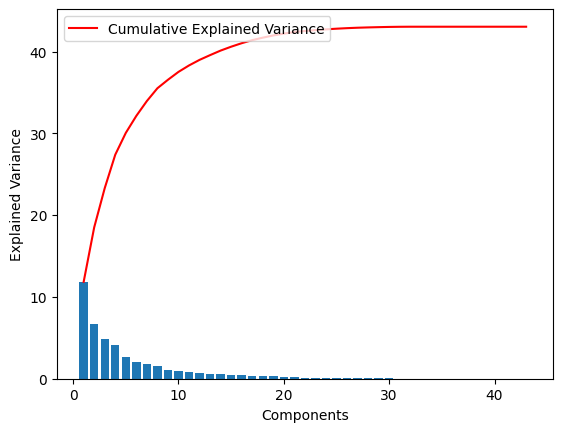

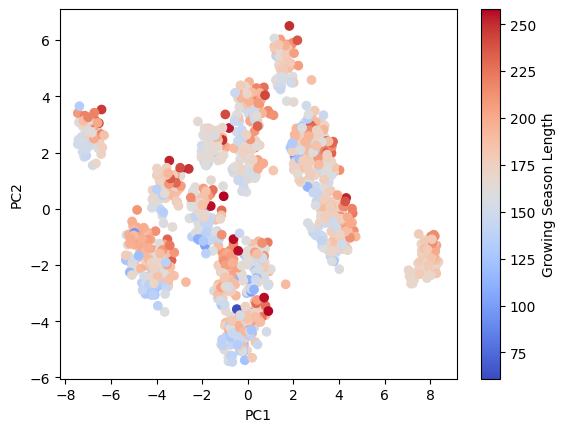

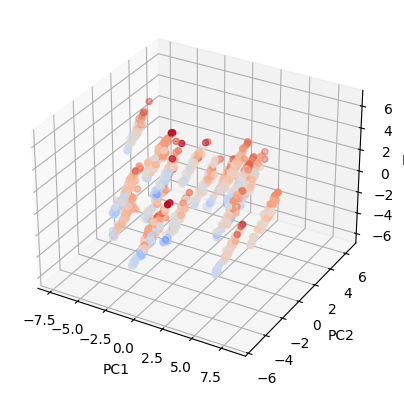

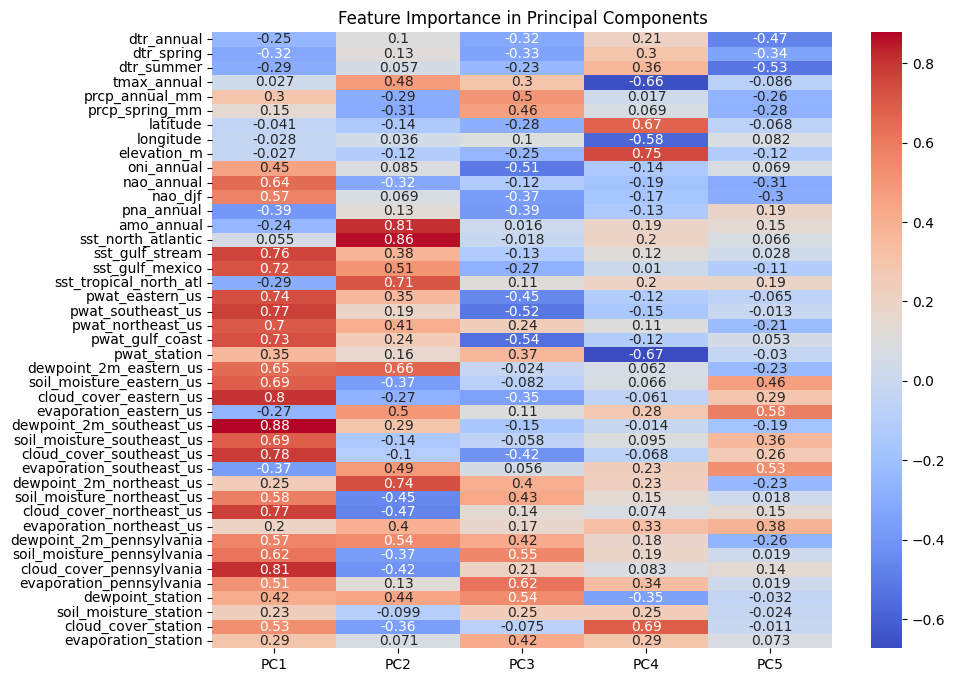

In [36]:
X_pca, y_pca = remove_nulls(pa_gs, X, y)
principal_component_analysis(X_pca, y_pca)

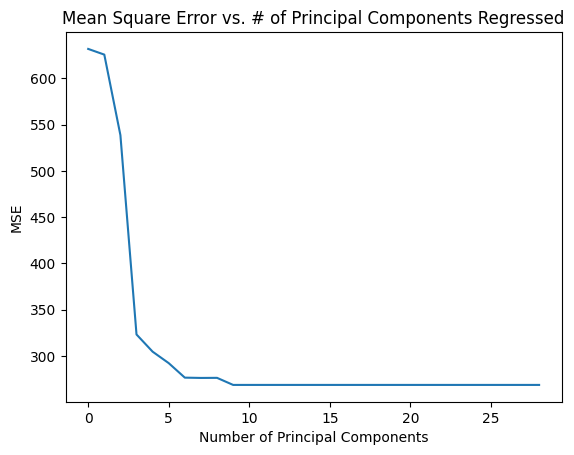

['MSE = 248.97359382291845',
 'RMSE = 15.778897104136222',
 'R Squared = 0.5970603156164145',
    coefficient
 0     0.339968
 1     1.120721
 2     3.714436
 3    -7.481415
 4     2.959908
 5    -2.491262
 6     3.100883
 7    -0.092117
 8     1.434052
 9     2.787565]

In [37]:
X_gs, y_gs = remove_nulls(pa_gs, X, y)
PCR(X_gs, y_gs, 10)

## Results and figures

*(Summarize key findings. Include any plots you made.)*

## Questions and blockers

* Not entirely confident in my code for Lasso Regressions and Ridge Regressions (they don't seem to be doing what they are made to do, i.e. improve the model... where has my code gone wrong?)
* Struggling to understand how to interpret Variograms, Moran I models, and Spatial Random Effects models as a whole (as well as how to code them in the first place)... suggestions on search queries that might provide more clarity rather than the abstract explanations I've found thus far?

## Plan for next week

- [ ] Lit Review Lit Review Lit Review --> do one large final stage of literature review (hopefully more focused on the guiding question, if we define it at this meeting) and combine all three into a cohesive final document
- [ ] Develop a better understanding of Spatial Random Effects Models for future use, continue improving comfort level and honing skills in Python 